In [5]:
import sys
print(sys.executable)

/Users/nabeelahmed/Desktop/intern_task1/.venv/bin/python


In [6]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("../data/cleaned/cleaned_sales_dataset.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Order_Year,Order_Month,Order_Month_Name,Age_Group
0,ORD100002,2025-02-25,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,2,February,26-35
1,ORD100003,2025-10-14,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,10,October,56-65
2,ORD100004,2025-05-13,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,5,May,56-65
3,ORD100005,2025-12-02,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,12,December,56-65
4,ORD100006,2025-11-20,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,11,November,36-45


In [3]:
print(df.shape)
print(df.columns.tolist())

(1000, 16)
['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Total_Sales', 'Order_Year', 'Order_Month', 'Order_Month_Name', 'Age_Group']


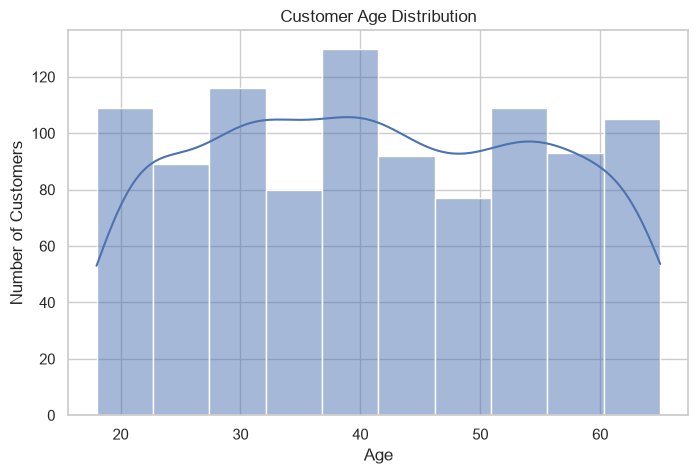

In [4]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Age"], bins=10, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

### Insight
The age distribution shows how customers are spread across different age groups. This helps identify the dominant customer demographic and can support targeted marketing and customer segmentation decisions.

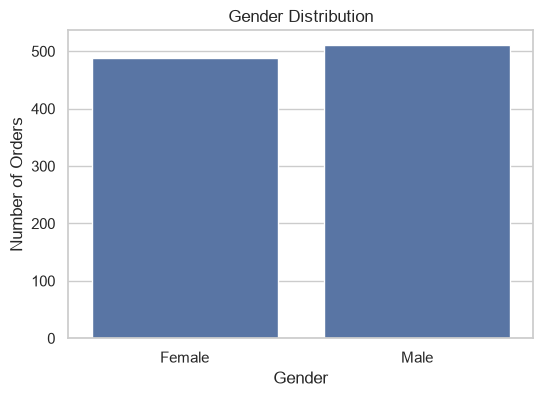

In [5]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Orders")

plt.show()

### Insight
The gender distribution provides an overview of customer representation in the dataset. It can help determine whether purchasing activity is concentrated within a particular gender segment.

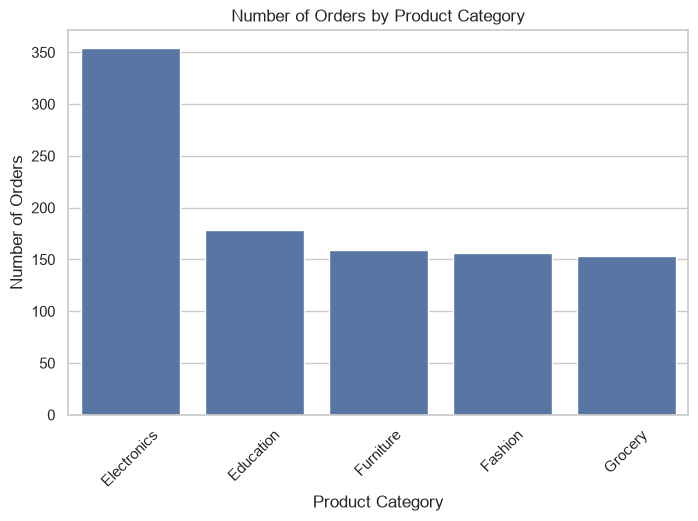

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Category",
    order=df["Category"].value_counts().index
)

plt.title("Number of Orders by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

### Insight
This visualization compares the number of orders across product categories. Categories with higher order volumes indicate stronger customer demand and may deserve greater inventory and marketing focus.

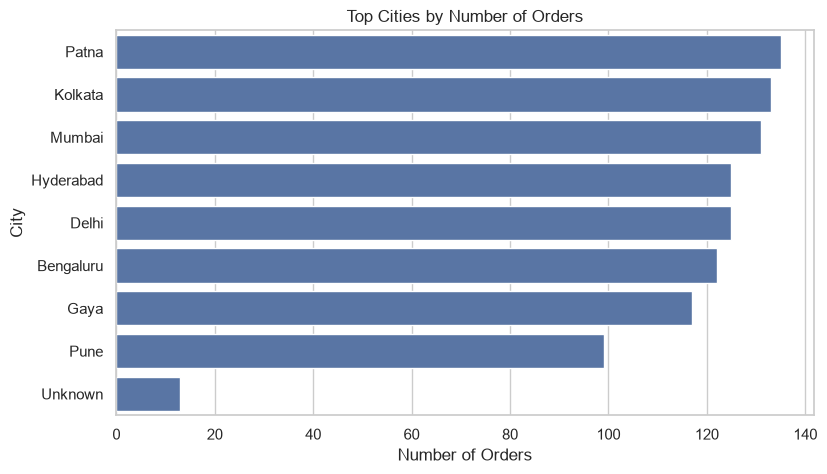

In [7]:
city_counts = df["City"].value_counts().head(10)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=city_counts.values,
    y=city_counts.index
)

plt.title("Top Cities by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("City")

plt.show()

### Insight
The chart identifies the cities generating the highest number of orders. These locations represent important geographic markets and may be useful for regional marketing and sales strategies.

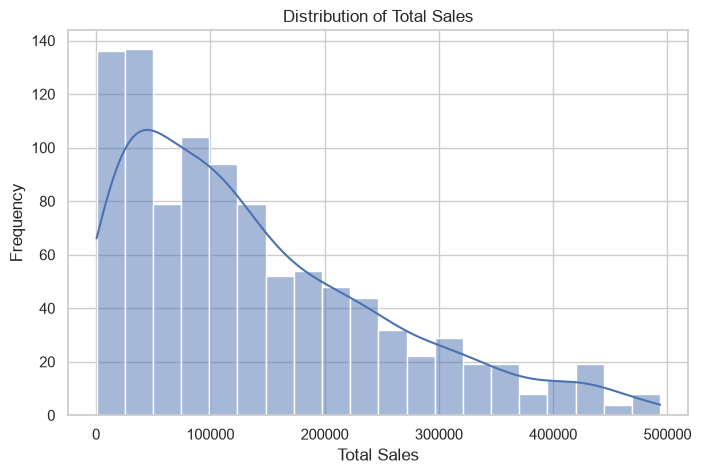

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Total_Sales"], bins=20, kde=True)

plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")

plt.show()

### Insight
The distribution of total sales shows how transaction values are spread across the dataset. It helps identify whether most orders are low, medium, or high value and whether a small number of transactions contribute disproportionately to revenue.

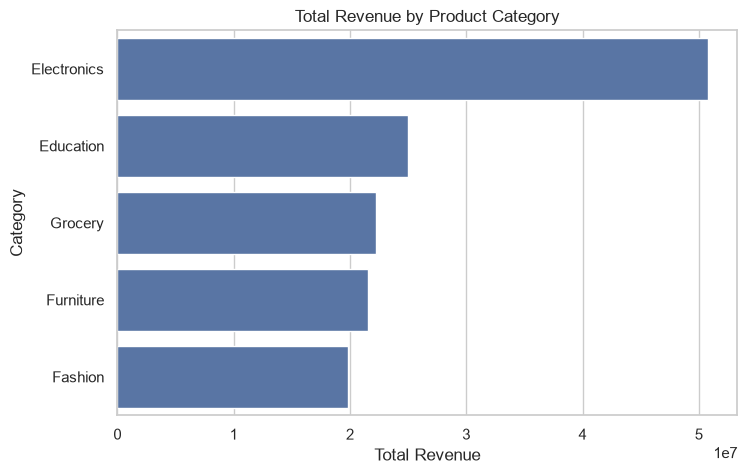

Category
Electronics    50778581.70
Education      25031689.40
Grocery        22231711.28
Furniture      21521561.48
Fashion        19835895.79
Name: Total_Sales, dtype: float64

In [9]:
category_revenue = (
    df.groupby("Category")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Category")

plt.show()

category_revenue

### Insight
Electronics is the highest-revenue product category, generating approximately 50.78 million in sales and contributing about 36.4% of total revenue. Education ranks second with approximately 25.03 million, followed by Grocery, Furniture, and Fashion. This shows that Electronics is the strongest revenue-driving category and should receive significant attention in inventory planning and marketing strategies.

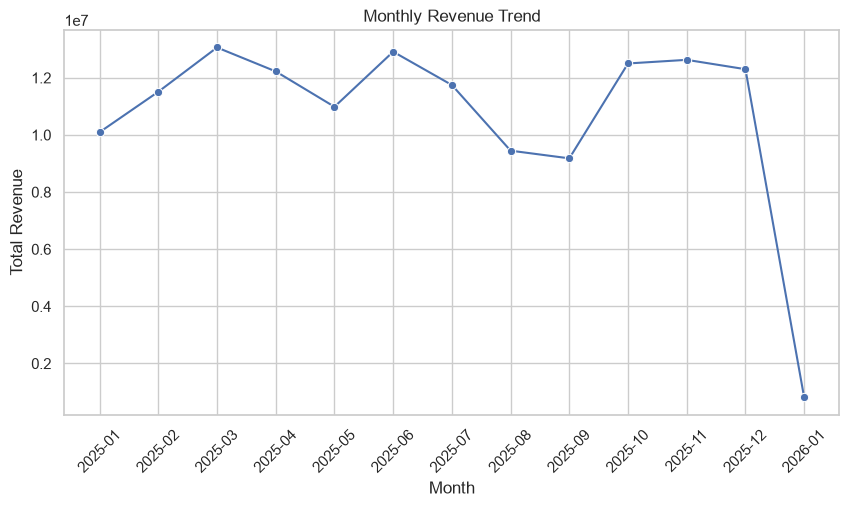

,Order_Year,Order_Month,Total_Sales,Year_Month
0,2025,1,10096190.73,2025-01
1,2025,2,11511181.46,2025-02
2,2025,3,13059899.94,2025-03
3,2025,4,12222700.17,2025-04
4,2025,5,10984689.25,2025-05
5,2025,6,12912332.64,2025-06
6,2025,7,11746226.80,2025-07
7,2025,8,9448471.22,2025-08
8,2025,9,9179896.29,2025-09
9,2025,10,12500936.50,2025-10


In [10]:
monthly_revenue = (
    df.groupby(["Order_Year", "Order_Month"])["Total_Sales"]
    .sum()
    .reset_index()
)

monthly_revenue["Year_Month"] = (
    monthly_revenue["Order_Year"].astype(str)
    + "-"
    + monthly_revenue["Order_Month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_revenue,
    x="Year_Month",
    y="Total_Sales",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

monthly_revenue

### Insight
Revenue fluctuates throughout 2025 rather than following a steady upward or downward trend. March recorded the highest monthly revenue at approximately 13.06 million, followed by June at 12.91 million and November at 12.63 million. September recorded the lowest full-month revenue at approximately 9.18 million. The January 2026 value is substantially lower and may represent a partial month, so it should not be directly compared with complete 2025 months.

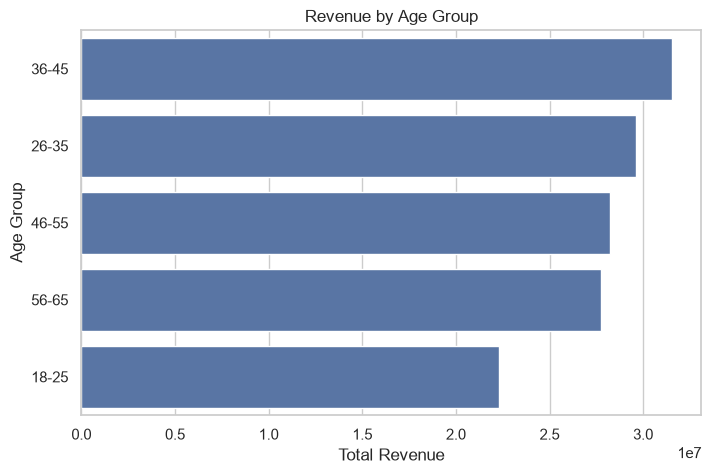

Age_Group
36-45    31533245.71
26-35    29632336.96
46-55    28216508.63
56-65    27733251.41
18-25    22284096.94
Name: Total_Sales, dtype: float64

In [11]:
age_group_revenue = (
    df.groupby("Age_Group", observed=False)["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=age_group_revenue.values,
    y=age_group_revenue.index
)

plt.title("Revenue by Age Group")
plt.xlabel("Total Revenue")
plt.ylabel("Age Group")

plt.show()

age_group_revenue

### Insight
Customers aged 36–45 generated the highest total revenue at approximately 31.53 million. The 26–35 group ranked second with approximately 29.63 million, while the 46–55 and 56–65 groups also contributed strongly. Customers aged 18–25 generated the lowest revenue at approximately 22.28 million. This indicates that middle-aged customers, particularly those between 36 and 45, represent the most valuable customer segment by revenue.

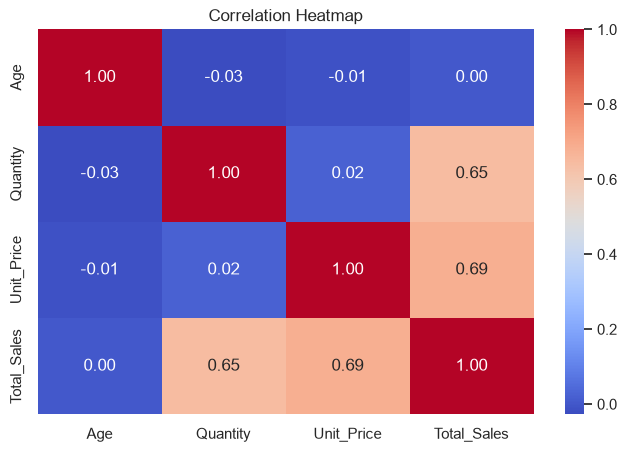

,Age,Quantity,Unit_Price,Total_Sales
Age,1.000000,-0.027666,-0.011955,0.001294
Quantity,-0.027666,1.000000,0.021855,0.646641
Unit_Price,-0.011955,0.021855,1.000000,0.686303
Total_Sales,0.001294,0.646641,0.686303,1.000000


In [12]:
numeric_df = df[
    ["Age", "Quantity", "Unit_Price", "Total_Sales"]
]

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

correlation_matrix

### Insight
Total Sales has a strong positive correlation with Unit Price (0.69) and Quantity (0.65). This means higher-priced products and larger quantities are the main drivers of transaction value. Age has almost no correlation with Total Sales (0.00), suggesting that customer age alone does not strongly influence how much is spent per order.

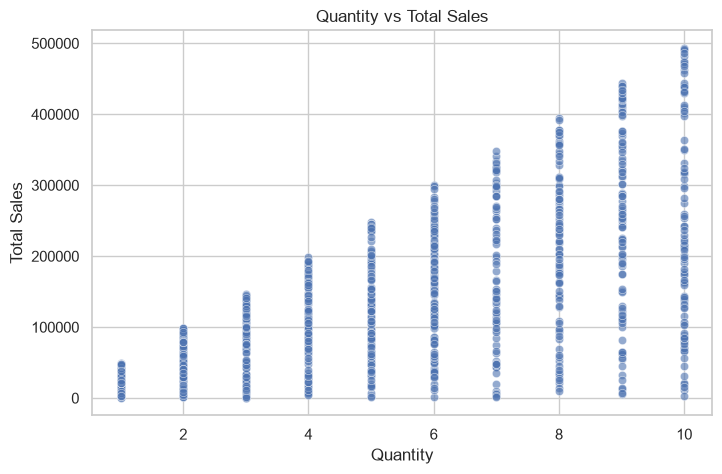

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Total_Sales",
    alpha=0.6
)

plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")

plt.show()

### Insight
The scatter plot shows a clear positive relationship between Quantity and Total Sales. Orders with larger quantities generally generate higher sales values, although the final transaction amount also depends on the Unit Price of the product.

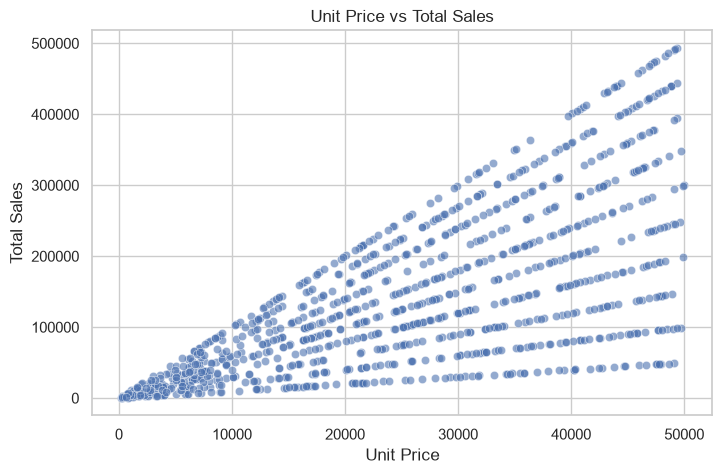

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Unit_Price",
    y="Total_Sales",
    alpha=0.6
)

plt.title("Unit Price vs Total Sales")
plt.xlabel("Unit Price")
plt.ylabel("Total Sales")

plt.show()

### Insight
Unit Price shows a strong positive relationship with Total Sales. Higher-priced products tend to produce larger transaction values, making product pricing an important revenue driver.

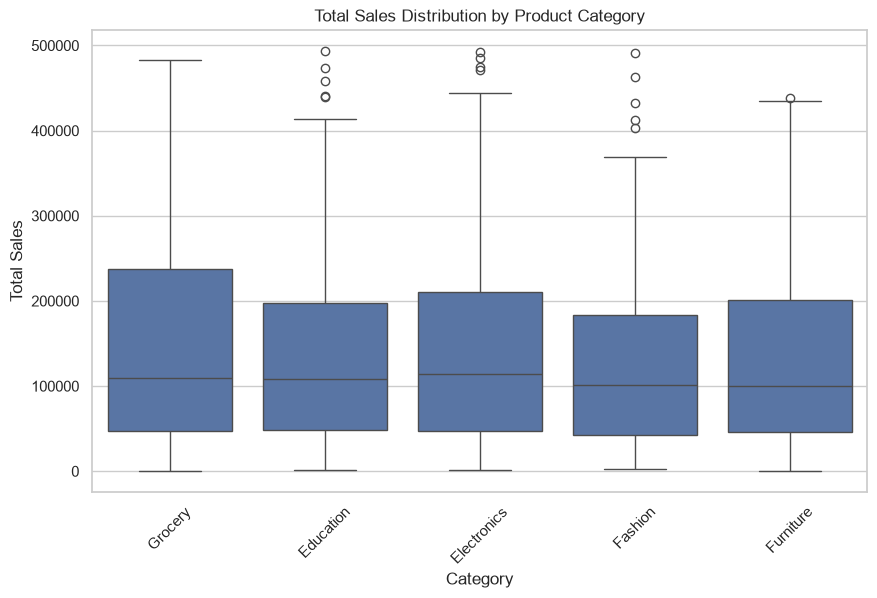

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Category",
    y="Total_Sales"
)

plt.title("Total Sales Distribution by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

### Insight
The distribution of Total Sales varies noticeably across product categories. Categories with higher-priced products tend to show larger transaction values and wider variation in sales. This helps identify categories that contribute more high-value orders.

In [16]:
import sqlite3

conn = sqlite3.connect("../data/sales_data.db")

df.to_sql(
    "sales_data",
    conn,
    if_exists="replace",
    index=False
)

print("SQL table created successfully.")

SQL table created successfully.


In [17]:
query = """
SELECT COUNT(*) AS Total_Rows
FROM sales_data;
"""

pd.read_sql_query(query, conn)

,Total_Rows
0,1000


In [18]:
query1 = """
SELECT
    Category,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM sales_data
GROUP BY Category
ORDER BY Total_Revenue DESC;
"""

result1 = pd.read_sql_query(query1, conn)
result1

,Category,Total_Revenue
0,Electronics,50778581.70
1,Education,25031689.40
2,Grocery,22231711.28
3,Furniture,21521561.48
4,Fashion,19835895.79


### Insight
Electronics is the strongest-performing category by revenue, significantly outperforming all other categories. This indicates that Electronics is the primary revenue driver in the dataset.

In [20]:
query2 = """
SELECT
    City,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM sales_data
GROUP BY City
ORDER BY Total_Revenue DESC
LIMIT 10;
"""

result2 = pd.read_sql_query(query2, conn)
result2

,City,Total_Revenue
0,Patna,19285966.89
1,Kolkata,18884349.57
2,Bengaluru,18773574.32
3,Mumbai,18757050.17
4,Hyderabad,17166766.87
5,Delhi,16097079.00
6,Pune,14513175.90
7,Gaya,14380859.39
8,Unknown,1540617.54


### Insight
The top-performing cities contribute a substantial share of total revenue. These locations should be considered priority markets for targeted promotions, inventory allocation, and customer acquisition campaigns.

In [21]:
query3 = """
SELECT
    Order_Year,
    Order_Month,
    ROUND(SUM(Total_Sales), 2) AS Monthly_Revenue
FROM sales_data
GROUP BY Order_Year, Order_Month
ORDER BY Order_Year, Order_Month;
"""

result3 = pd.read_sql_query(query3, conn)
result3

,Order_Year,Order_Month,Monthly_Revenue
0,2025,1,10096190.73
1,2025,2,11511181.46
2,2025,3,13059899.94
3,2025,4,12222700.17
4,2025,5,10984689.25
5,2025,6,12912332.64
6,2025,7,11746226.80
7,2025,8,9448471.22
8,2025,9,9179896.29
9,2025,10,12500936.50


### Insight
Monthly revenue fluctuates throughout the year, with some months performing noticeably better than others. This suggests seasonality or changing customer demand across different periods.

In [22]:
query4 = """
SELECT
    Age_Group,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM sales_data
GROUP BY Age_Group
ORDER BY Total_Revenue DESC;
"""

result4 = pd.read_sql_query(query4, conn)
result4

,Age_Group,Total_Revenue
0,36-45,31533245.71
1,26-35,29632336.96
2,46-55,28216508.63
3,56-65,27733251.41
4,18-25,22284096.94


### Insight
Customers aged 36–45 generate the highest total revenue, making this the most valuable age segment based on overall sales contribution.

In [23]:
query5 = """
SELECT
    Category,
    ROUND(AVG(Total_Sales), 2) AS Average_Order_Value
FROM sales_data
GROUP BY Category
ORDER BY Average_Order_Value DESC;
"""

result5 = pd.read_sql_query(query5, conn)
result5

,Category,Average_Order_Value
0,Grocery,145305.30
1,Electronics,143442.32
2,Education,140627.47
3,Furniture,135355.73
4,Fashion,127153.18


### Insight
Average order value varies considerably by category. Categories with higher-value products generate larger transaction amounts even when their order volumes are lower.

In [24]:
query6 = """
SELECT
    Product,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM sales_data
GROUP BY Product
ORDER BY Total_Revenue DESC
LIMIT 5;
"""

result6 = pd.read_sql_query(query6, conn)
result6

,Product,Total_Revenue
0,Laptop,25443008.51
1,Mobile,25335573.19
2,Book,25031689.40
3,Rice,22231711.28
4,Chair,21521561.48


### Insight
A small number of products contribute disproportionately to total revenue. These products are strategically important and should be closely monitored for inventory availability and demand.

In [25]:
query7 = """
SELECT
    Age_Group,
    Gender,
    ROUND(AVG(Total_Sales), 2) AS Average_Transaction_Value,
    COUNT(*) AS Number_Of_Orders
FROM sales_data
GROUP BY Age_Group, Gender
ORDER BY Average_Transaction_Value DESC;
"""

result7 = pd.read_sql_query(query7, conn)
result7

,Age_Group,Gender,Average_Transaction_Value,Number_Of_Orders
0,18-25,Female,158427.17,71
1,26-35,Male,154587.62,121
2,36-45,Male,145911.14,99
3,46-55,Female,142966.85,91
4,56-65,Male,140547.88,93
5,56-65,Female,139640.94,105
6,36-45,Female,137806.80,124
7,46-55,Male,136995.72,111
8,18-25,Male,126847.91,87
9,26-35,Female,111502.40,98


### Insight
Combining age group and gender reveals differences in average transaction value between customer segments. This can support more targeted customer segmentation and marketing strategies.

In [26]:
import os

os.makedirs("../sql/query_results", exist_ok=True)

result1.to_csv("../sql/query_results/query1_revenue_by_category.csv", index=False)
result2.to_csv("../sql/query_results/query2_revenue_by_city.csv", index=False)
result3.to_csv("../sql/query_results/query3_monthly_revenue.csv", index=False)
result4.to_csv("../sql/query_results/query4_revenue_by_age_group.csv", index=False)
result5.to_csv("../sql/query_results/query5_avg_order_value_by_category.csv", index=False)
result6.to_csv("../sql/query_results/query6_top_products.csv", index=False)
result7.to_csv("../sql/query_results/query7_customer_segments.csv", index=False)

print("All SQL query results saved successfully.")

All SQL query results saved successfully.


In [27]:
total_revenue = df["Total_Sales"].sum()
total_orders = df["Order_ID"].nunique()
average_order_value = df["Total_Sales"].mean()
total_quantity = df["Quantity"].sum()

top_category = (
    df.groupby("Category")["Total_Sales"]
    .sum()
    .idxmax()
)

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))
print("Total Quantity Sold:", total_quantity)
print("Top Category:", top_category)

Total Revenue: 139399439.65
Total Orders: 1000
Average Order Value: 139399.44
Total Quantity Sold: 5435
Top Category: Electronics


In [28]:
dashboard_category = (
    df.groupby("Category")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

dashboard_city = (
    df.groupby("City")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

dashboard_age = (
    df.groupby("Age_Group", observed=False)["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

dashboard_products = (
    df.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

In [29]:
with pd.ExcelWriter("../dashboard/task2_dashboard_data.xlsx") as writer:
    dashboard_category.to_excel(writer, sheet_name="Revenue by Category", index=False)
    dashboard_city.to_excel(writer, sheet_name="Revenue by City", index=False)
    dashboard_age.to_excel(writer, sheet_name="Revenue by Age Group", index=False)
    dashboard_products.to_excel(writer, sheet_name="Top Products", index=False)
    monthly_revenue.to_excel(writer, sheet_name="Monthly Revenue", index=False)

print("Dashboard data exported successfully.")

Dashboard data exported successfully.


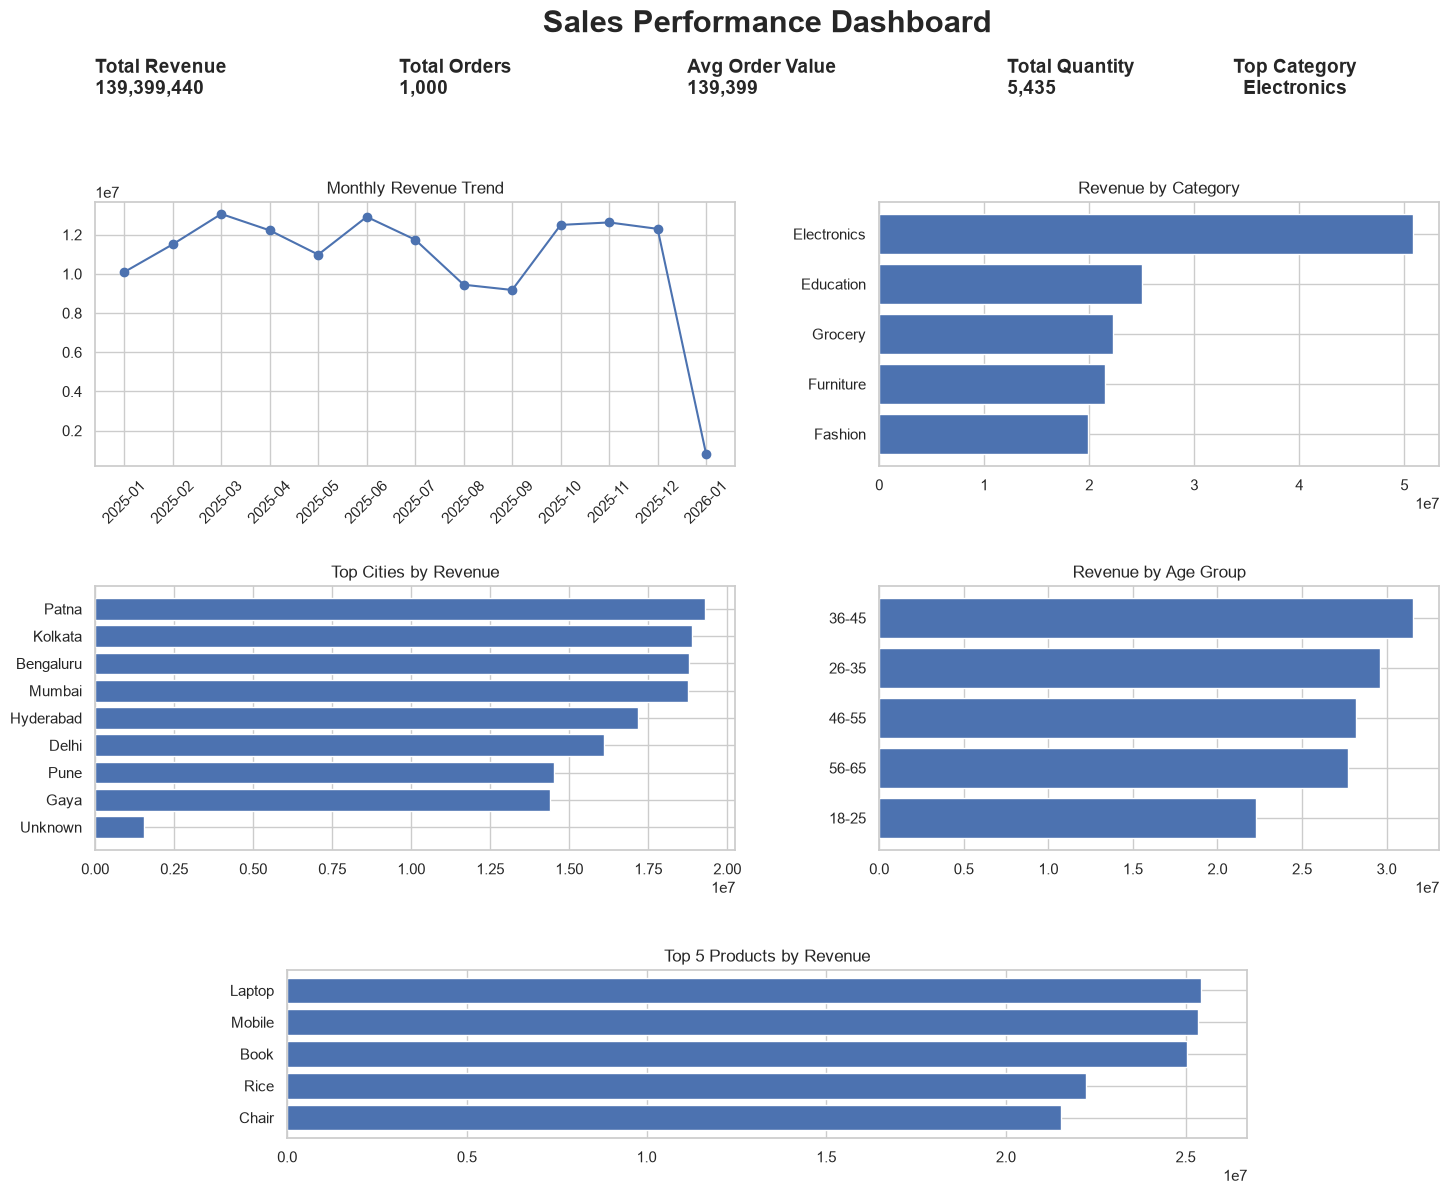

In [31]:
import os
import matplotlib.pyplot as plt

os.makedirs("../dashboard", exist_ok=True)

fig = plt.figure(figsize=(16, 12))

fig.suptitle("Sales Performance Dashboard", fontsize=22, fontweight="bold")

# KPI values
total_revenue = df["Total_Sales"].sum()
total_orders = df["Order_ID"].nunique()
average_order_value = df["Total_Sales"].mean()
total_quantity = df["Quantity"].sum()
top_category = df.groupby("Category")["Total_Sales"].sum().idxmax()

fig.text(0.08, 0.91, f"Total Revenue\n{total_revenue:,.0f}", fontsize=14, fontweight="bold")
fig.text(0.27, 0.91, f"Total Orders\n{total_orders:,}", fontsize=14, fontweight="bold")
fig.text(0.45, 0.91, f"Avg Order Value\n{average_order_value:,.0f}", fontsize=14, fontweight="bold")
fig.text(0.65, 0.91, f"Total Quantity\n{total_quantity:,}", fontsize=14, fontweight="bold")
fig.text(0.83, 0.91, f"Top Category\n{top_category}", fontsize=14, fontweight="bold", ha="center")

# Monthly revenue
ax1 = fig.add_axes([0.08, 0.60, 0.40, 0.22])

monthly_plot = (
    df.groupby(["Order_Year", "Order_Month"])["Total_Sales"]
    .sum()
    .reset_index()
)

monthly_plot["Year_Month"] = (
    monthly_plot["Order_Year"].astype(str)
    + "-"
    + monthly_plot["Order_Month"].astype(str).str.zfill(2)
)

ax1.plot(monthly_plot["Year_Month"], monthly_plot["Total_Sales"], marker="o")
ax1.set_title("Monthly Revenue Trend")
ax1.tick_params(axis="x", rotation=45)

# Revenue by category
ax2 = fig.add_axes([0.57, 0.60, 0.35, 0.22])

category_plot = (
    df.groupby("Category")["Total_Sales"]
    .sum()
    .sort_values()
)

ax2.barh(category_plot.index, category_plot.values)
ax2.set_title("Revenue by Category")

# Revenue by city
ax3 = fig.add_axes([0.08, 0.28, 0.40, 0.22])

city_plot = (
    df.groupby("City")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

ax3.barh(city_plot.index, city_plot.values)
ax3.set_title("Top Cities by Revenue")

# Revenue by age group
ax4 = fig.add_axes([0.57, 0.28, 0.35, 0.22])

age_plot = (
    df.groupby("Age_Group", observed=False)["Total_Sales"]
    .sum()
    .sort_values()
)

ax4.barh(age_plot.index.astype(str), age_plot.values)
ax4.set_title("Revenue by Age Group")

# Top products
ax5 = fig.add_axes([0.20, 0.04, 0.60, 0.14])

product_plot = (
    df.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .sort_values()
)

ax5.barh(product_plot.index, product_plot.values)
ax5.set_title("Top 5 Products by Revenue")

plt.savefig(
    "../dashboard/task2_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()